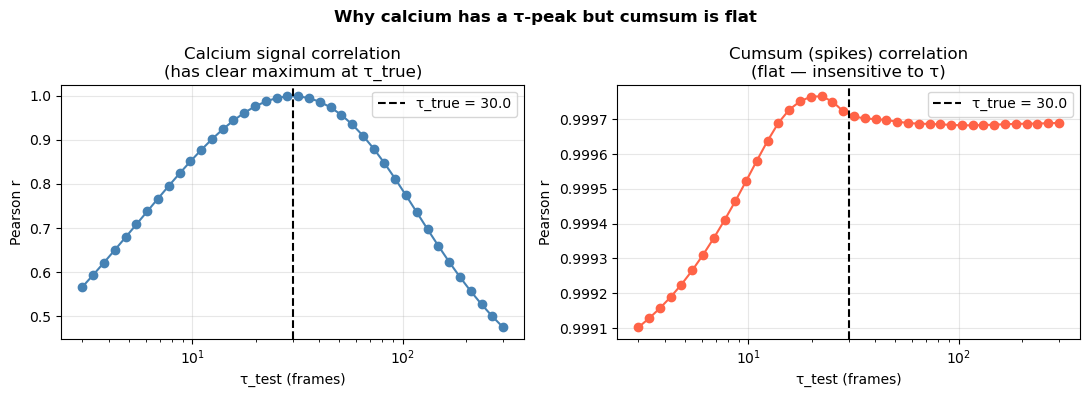

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

rng = np.random.default_rng(42)

# ── Synthetic ground truth ────────────────────────────────────────────────────
T        = 1000          # frames
fs       = 100.0         # Hz
tau_true = 30.0          # frames (true decay)
n_spikes = 80

spike_train = np.zeros(T)
spike_times = rng.choice(T, n_spikes, replace=False)
spike_train[spike_times] = 1.0

# Convolve with true exponential kernel
kernel_true = np.exp(-np.arange(T) / tau_true)
calcium     = np.convolve(spike_train, kernel_true)[:T]
calcium    += rng.normal(0, 0.05, T)   # a bit of noise

# ── Sweep tau ─────────────────────────────────────────────────────────────────
tau_sweep = np.logspace(np.log10(3), np.log10(300), 40)

corr_calcium = []
corr_cumsum  = []

x_true_cum = np.cumsum(spike_train)

for tau_test in tau_sweep:
    kernel_test = np.exp(-np.arange(T) / tau_test)

    # --- calcium metric: simulate calcium from TRUE spikes with tau_test ---
    sim_calcium = np.convolve(spike_train, kernel_test)[:T]
    corr_calcium.append(pearsonr(calcium, sim_calcium)[0])

    # --- cumsum metric: deconvolve with tau_test, then cumsum ---
    # Simple finite-difference deconvolution: rec[t] = cal[t] - cal[t-1]*exp(-1/tau)
    alpha = np.exp(-1.0 / tau_test)
    rec   = np.zeros(T)
    rec[0] = calcium[0]
    for t in range(1, T):
        rec[t] = calcium[t] - alpha * calcium[t - 1]
    rec = np.clip(rec, 0, None)   # non-negative
    corr_cumsum.append(pearsonr(x_true_cum, np.cumsum(rec))[0])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.semilogx(tau_sweep, corr_calcium, 'o-', color='steelblue')
ax1.axvline(tau_true, color='k', linestyle='--', label=f'τ_true = {tau_true}')
ax1.set_xlabel('τ_test (frames)')
ax1.set_ylabel('Pearson r')
ax1.set_title('Calcium signal correlation\n(has clear maximum at τ_true)')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.semilogx(tau_sweep, corr_cumsum, 'o-', color='tomato')
ax2.axvline(tau_true, color='k', linestyle='--', label=f'τ_true = {tau_true}')
ax2.set_xlabel('τ_test (frames)')
ax2.set_ylabel('Pearson r')
ax2.set_title('Cumsum (spikes) correlation\n(flat — insensitive to τ)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Why calcium has a τ-peak but cumsum is flat', fontweight='bold')
plt.tight_layout()
plt.show()
